<div>
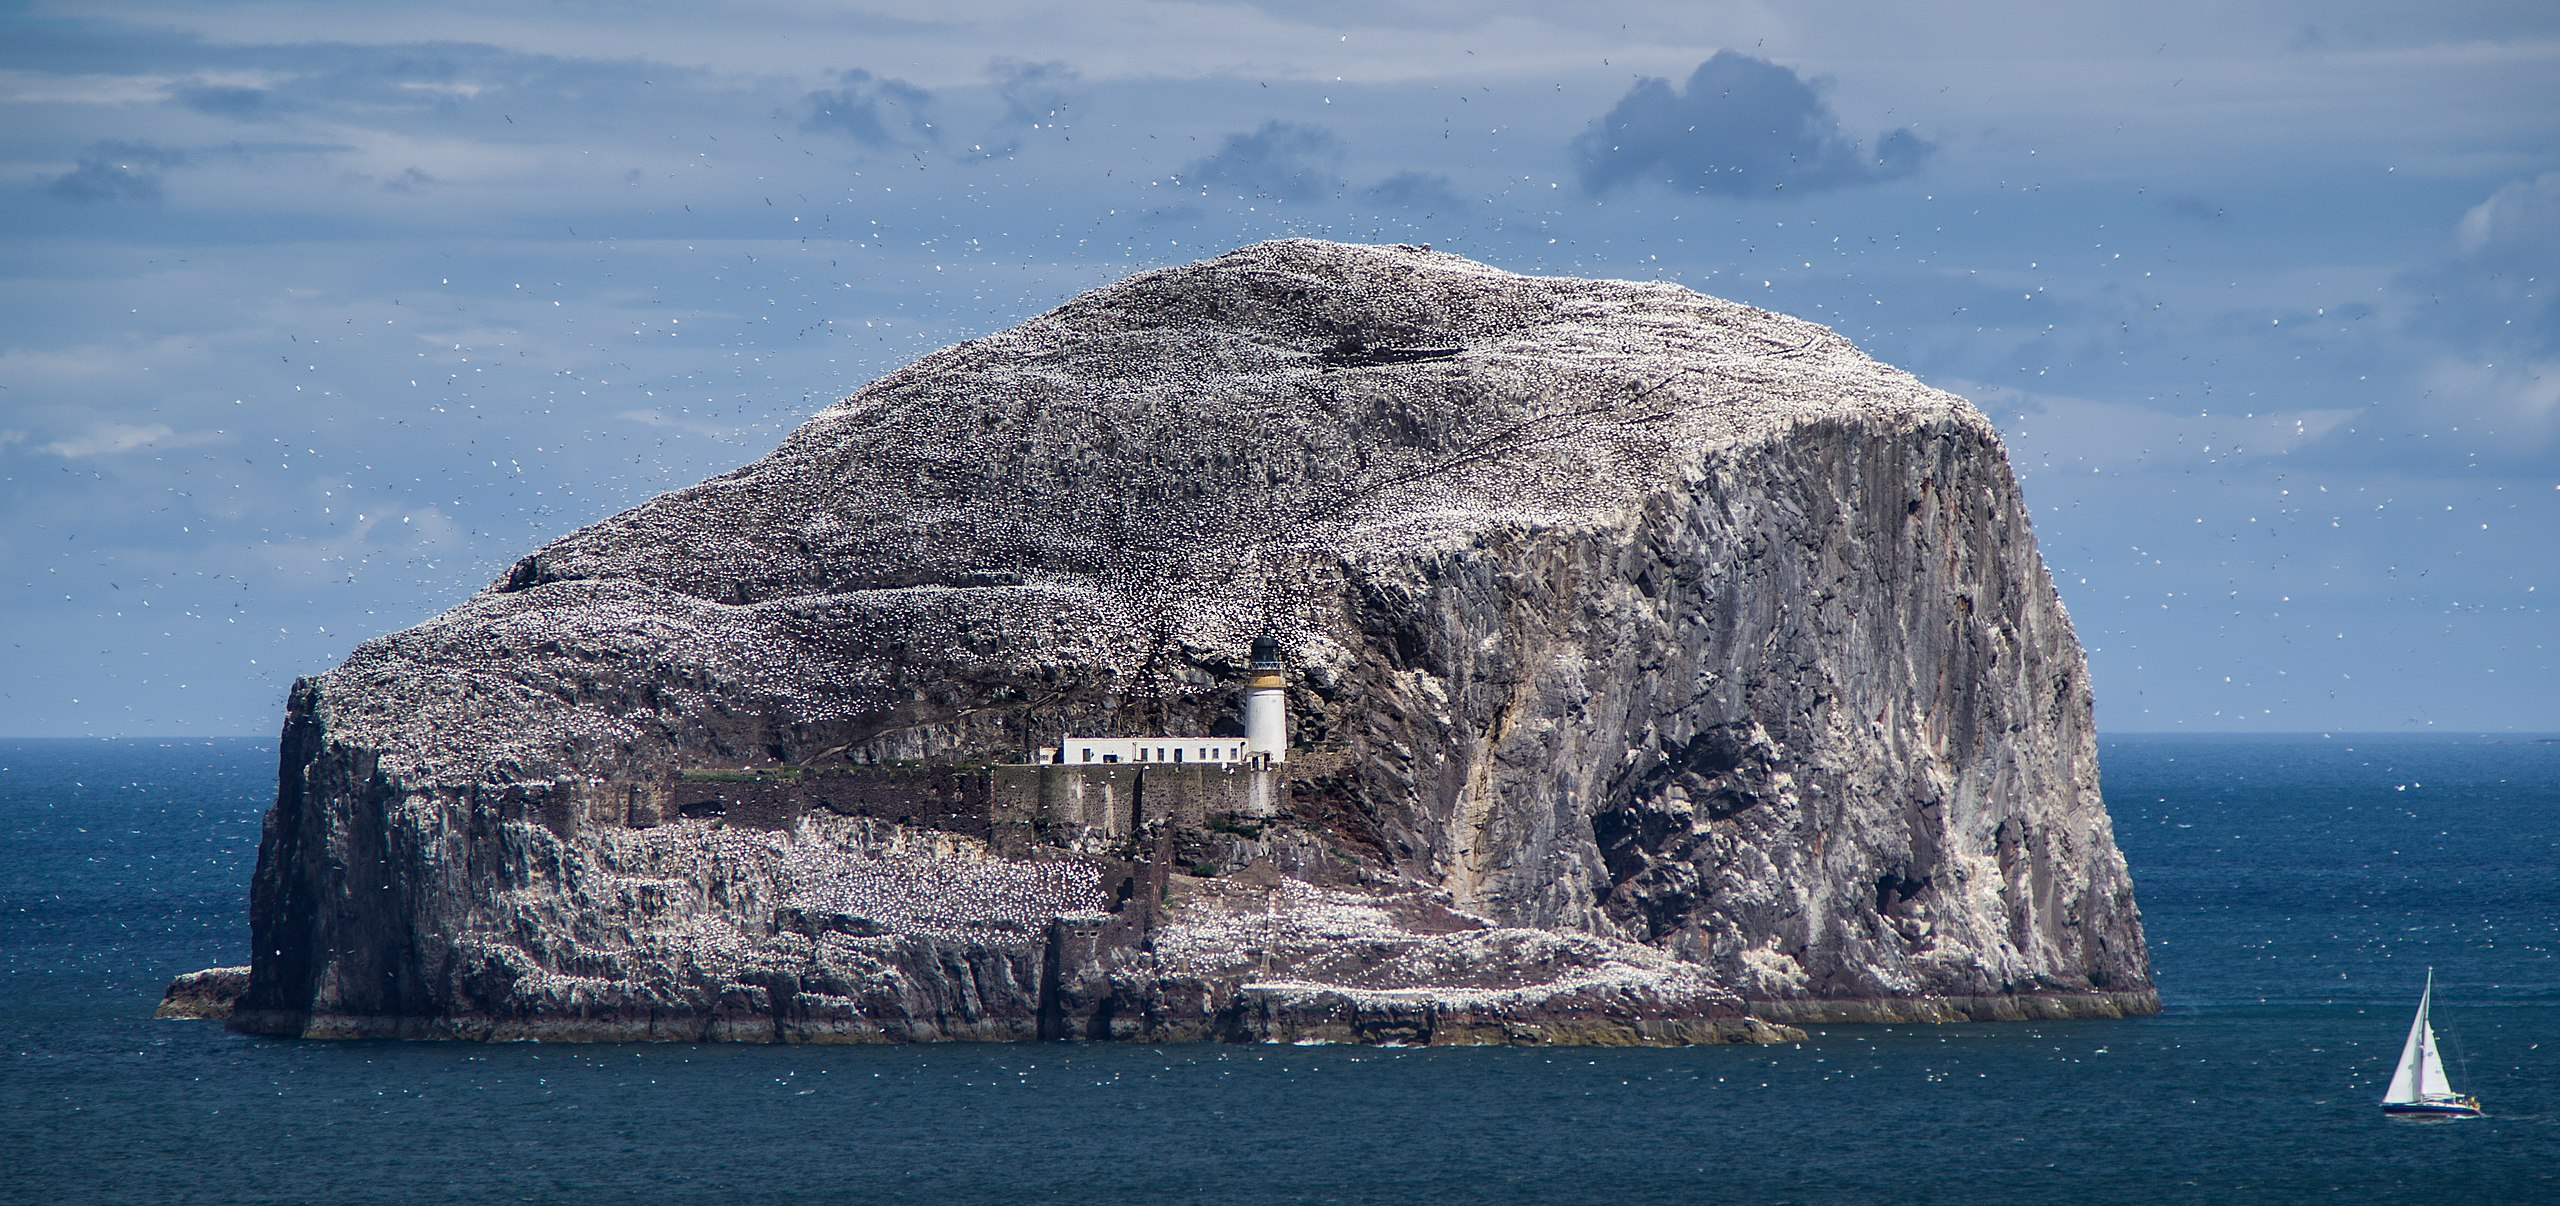
</div>

<div>
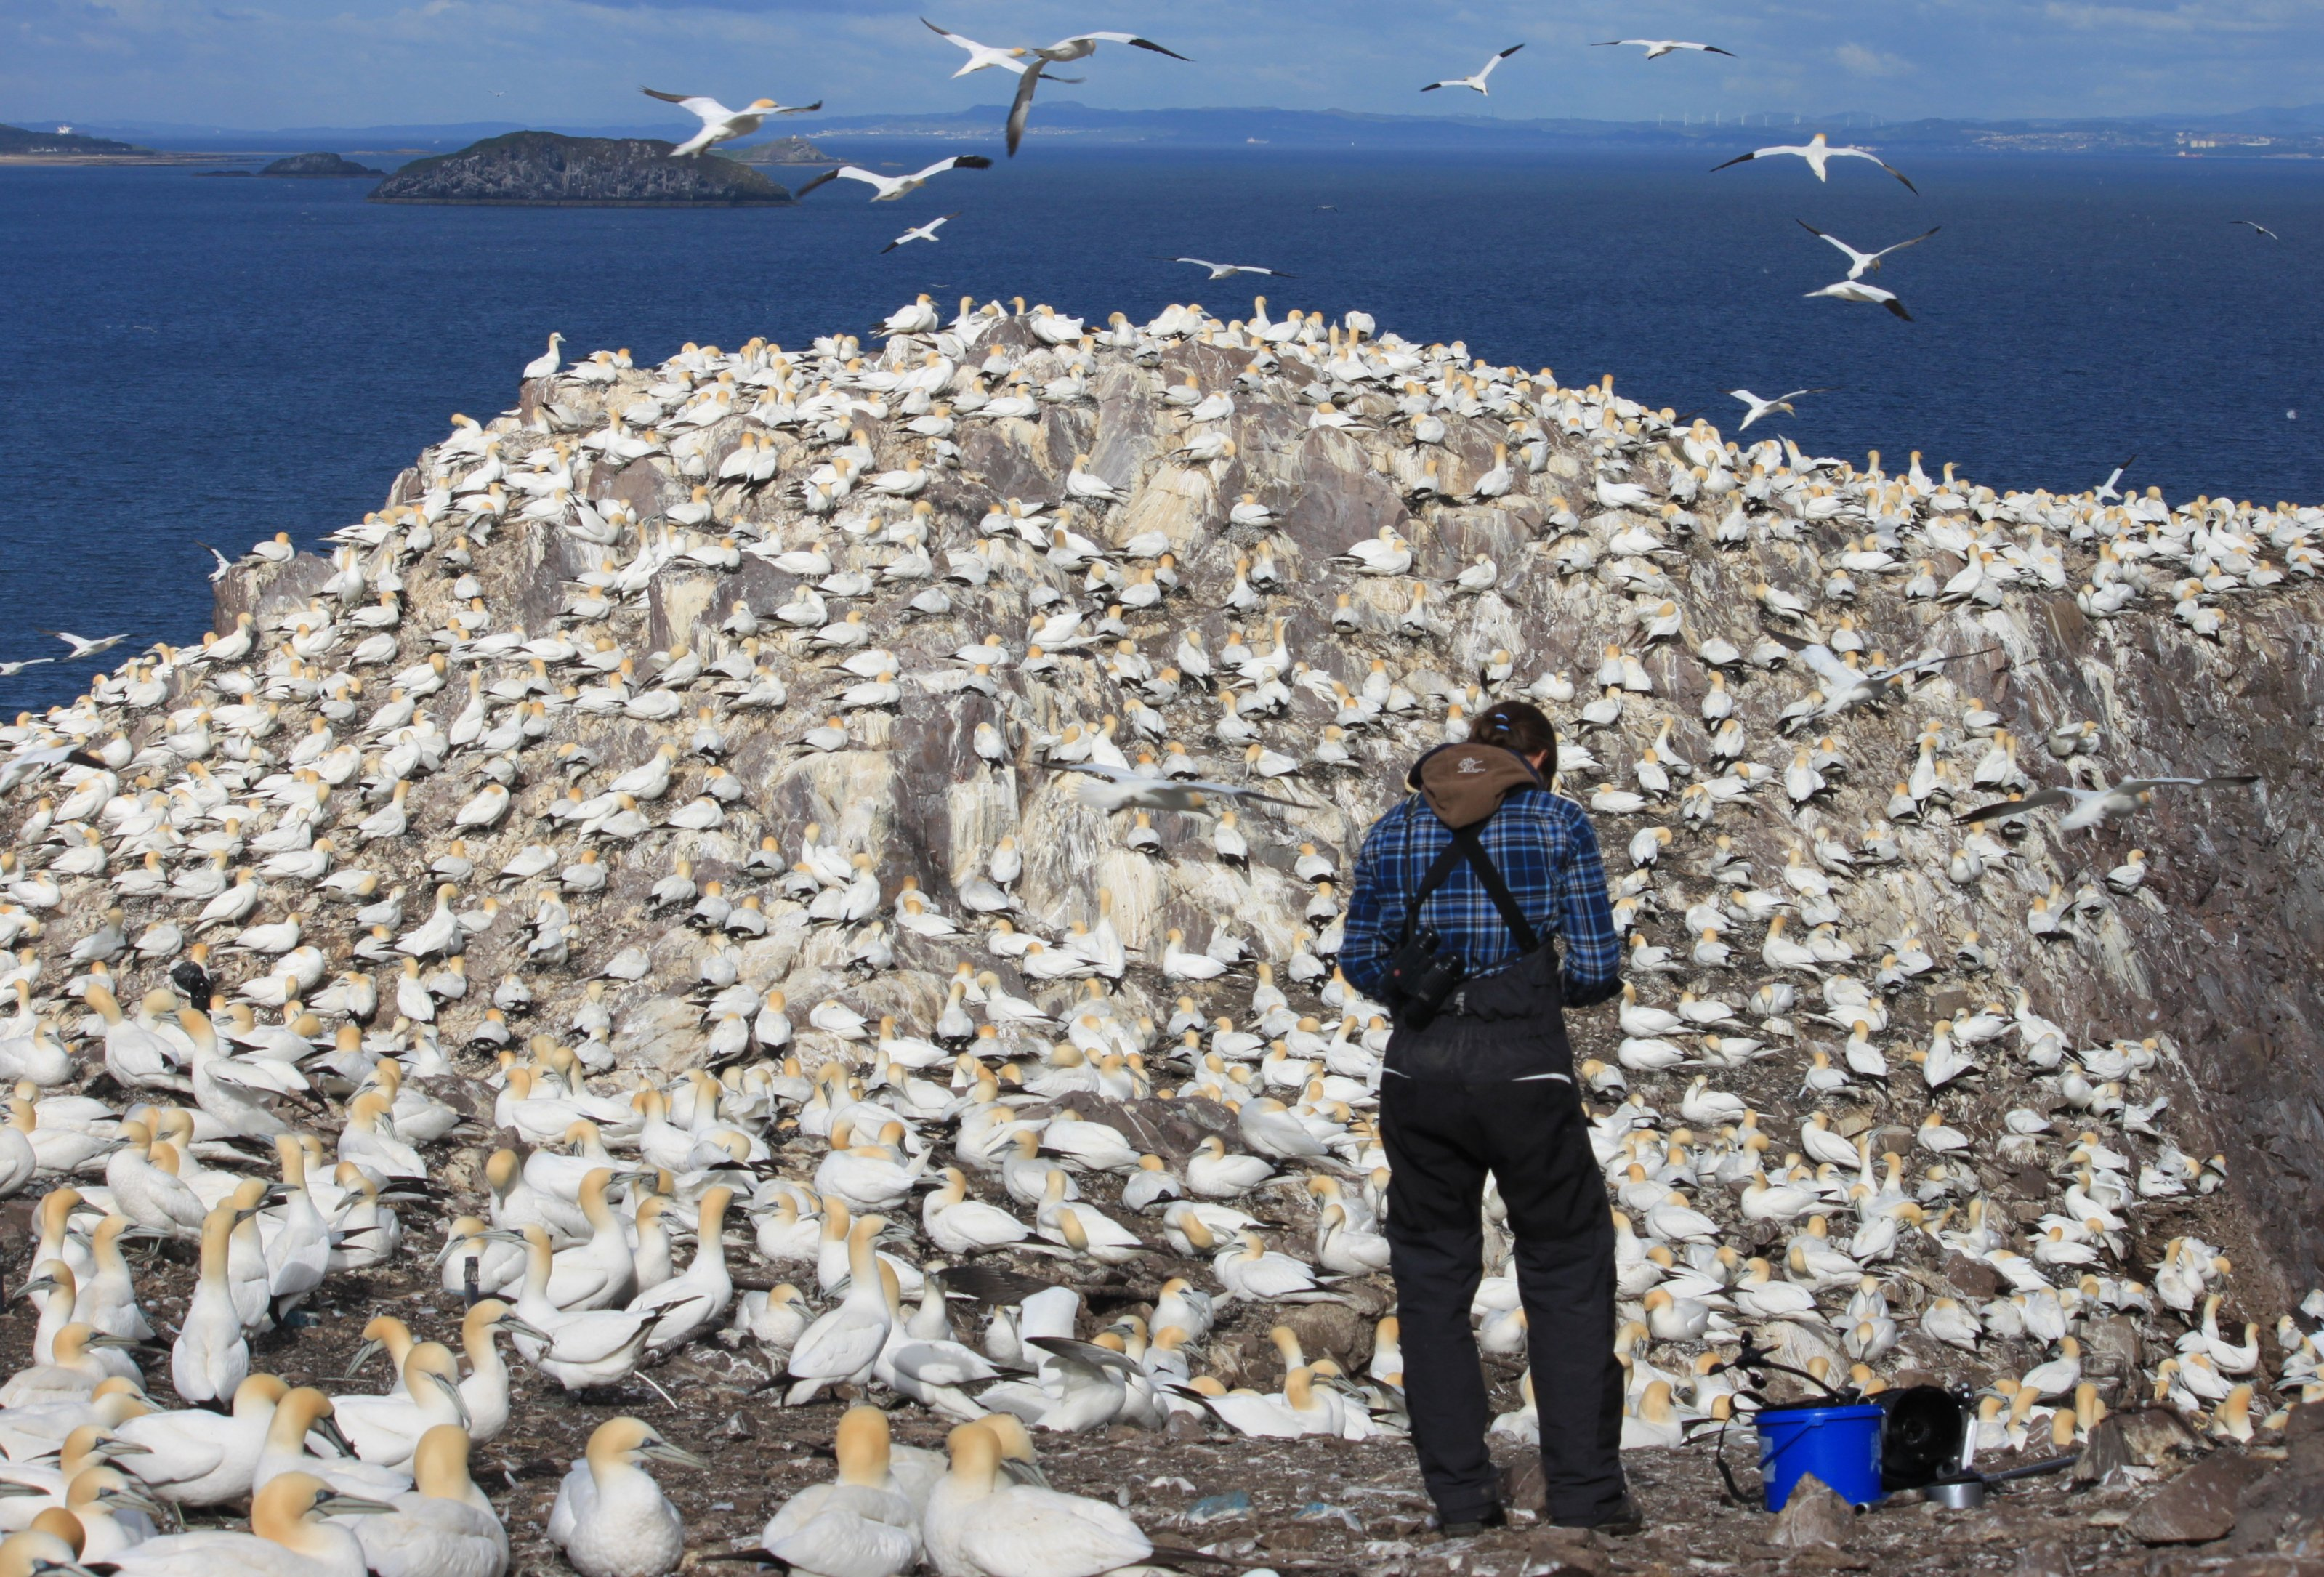
</div>

Are arrival times of a male and female breeding pair correlated?

# Import modules and set some seaborn styling

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

# import the pearson statistical function
from scipy.stats import pearsonr

# import interactive plots
from interactive_plots import *
%matplotlib widget

# set seaborn styles for a presentation
sns.set_style()
sns.set_context("talk")

# Read in the data and print it out

Data are dates of arrival of male and female breeding pairs after 1<sup>st</sup> March. 

In [22]:
gannets = pd.read_csv('../Datasets/gannets.csv', index_col=0)
gannets

,male,female
pair,,
1,19,22
2,20,28
3,23,17
4,17,21
5,15,18
6,24,23
7,11,17
8,21,25
9,20,24


# Plot the data to see what it looks like

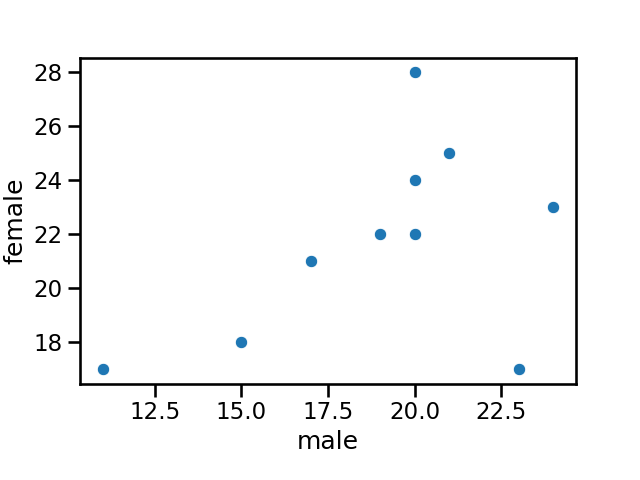

In [23]:
fig, ax = plt.subplots()
fig.canvas.toolbar_visible = False
fig.subplots_adjust(bottom=0.2)

sns.scatterplot(data=gannets, x='male', y='female', ax=ax);

Let's add some annotation to better interpret the data.

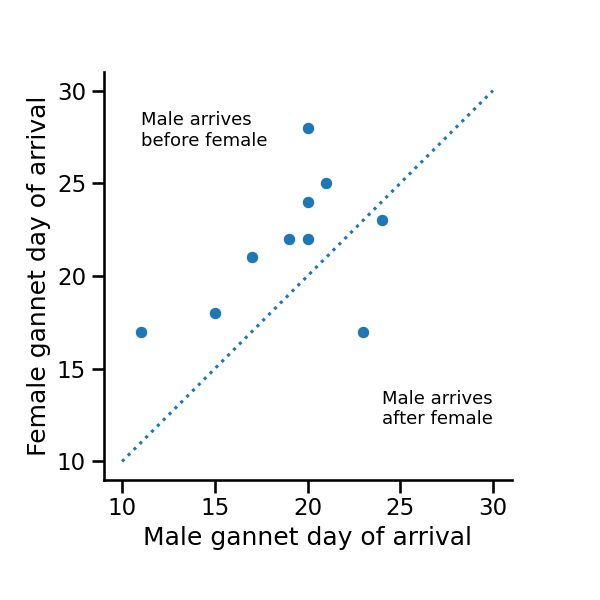

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.canvas.toolbar_visible = False
fig.subplots_adjust(bottom=0.2)
sns.scatterplot(data=gannets, x='male', y='female', ax=ax);
ax.set_xlabel('Male gannet day of arrival')
ax.set_ylabel('Female gannet day of arrival')
ax.text(11, 27, 'Male arrives\nbefore female', ha='left', size=13)
ax.text(24, 12, 'Male arrives\nafter female', ha='left', size=13)
ax.plot([10, 30], [10, 30], ls=':') # diagonal line y=x representing the same day of arrival
ax.set_aspect('equal') # equal aspect ratio to make the plot square
sns.despine() # remove right and top spines

# Two interesting things to note

<div>
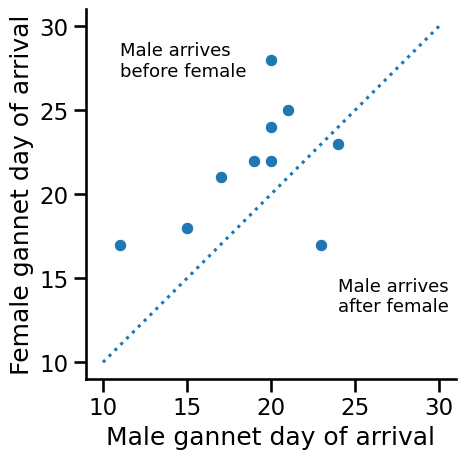
</div>

Most males arrive before females

# Two interesting things to note

<div>
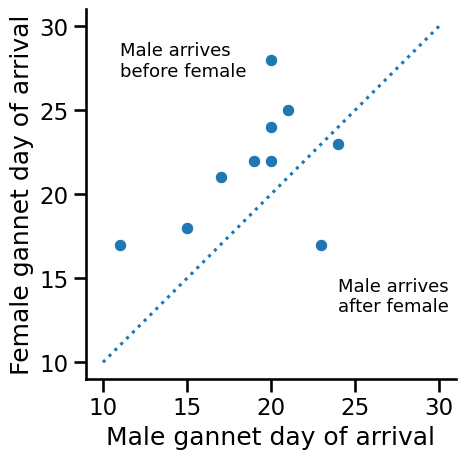
</div>

Most males arrive before females

There appears to be a positive correlation between arrival dates. That is, one of a pair arrives a few days after its mate.

Are arrival times of a male and female breeding pair correlated?

# Calculate the correlation coefficient

<div>
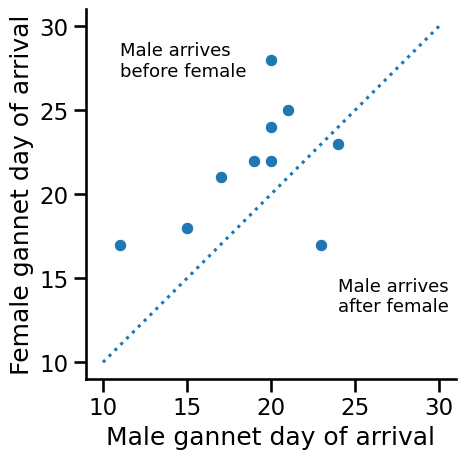
</div>

Also known as the pearson correlation coefficient after its developer Karl Pearson.

The pearson correlation coefficient is usually denoted *r*.

In [25]:
result = pearsonr( gannets['female'], gannets['male'] )

print( f'r = {result.statistic:.2f}' )

r = 0.46


A correlation coefficient of 0.46 is considered weak.

# What is a correlation coefficient?

A correlation coefficient measures the **strength** and **direction** of the association between two numerical variables.

In [ ]:
cor_coef_demo();

# What is the correlation coefficient for the whole population of 52,000 breeding pairs?

<div>
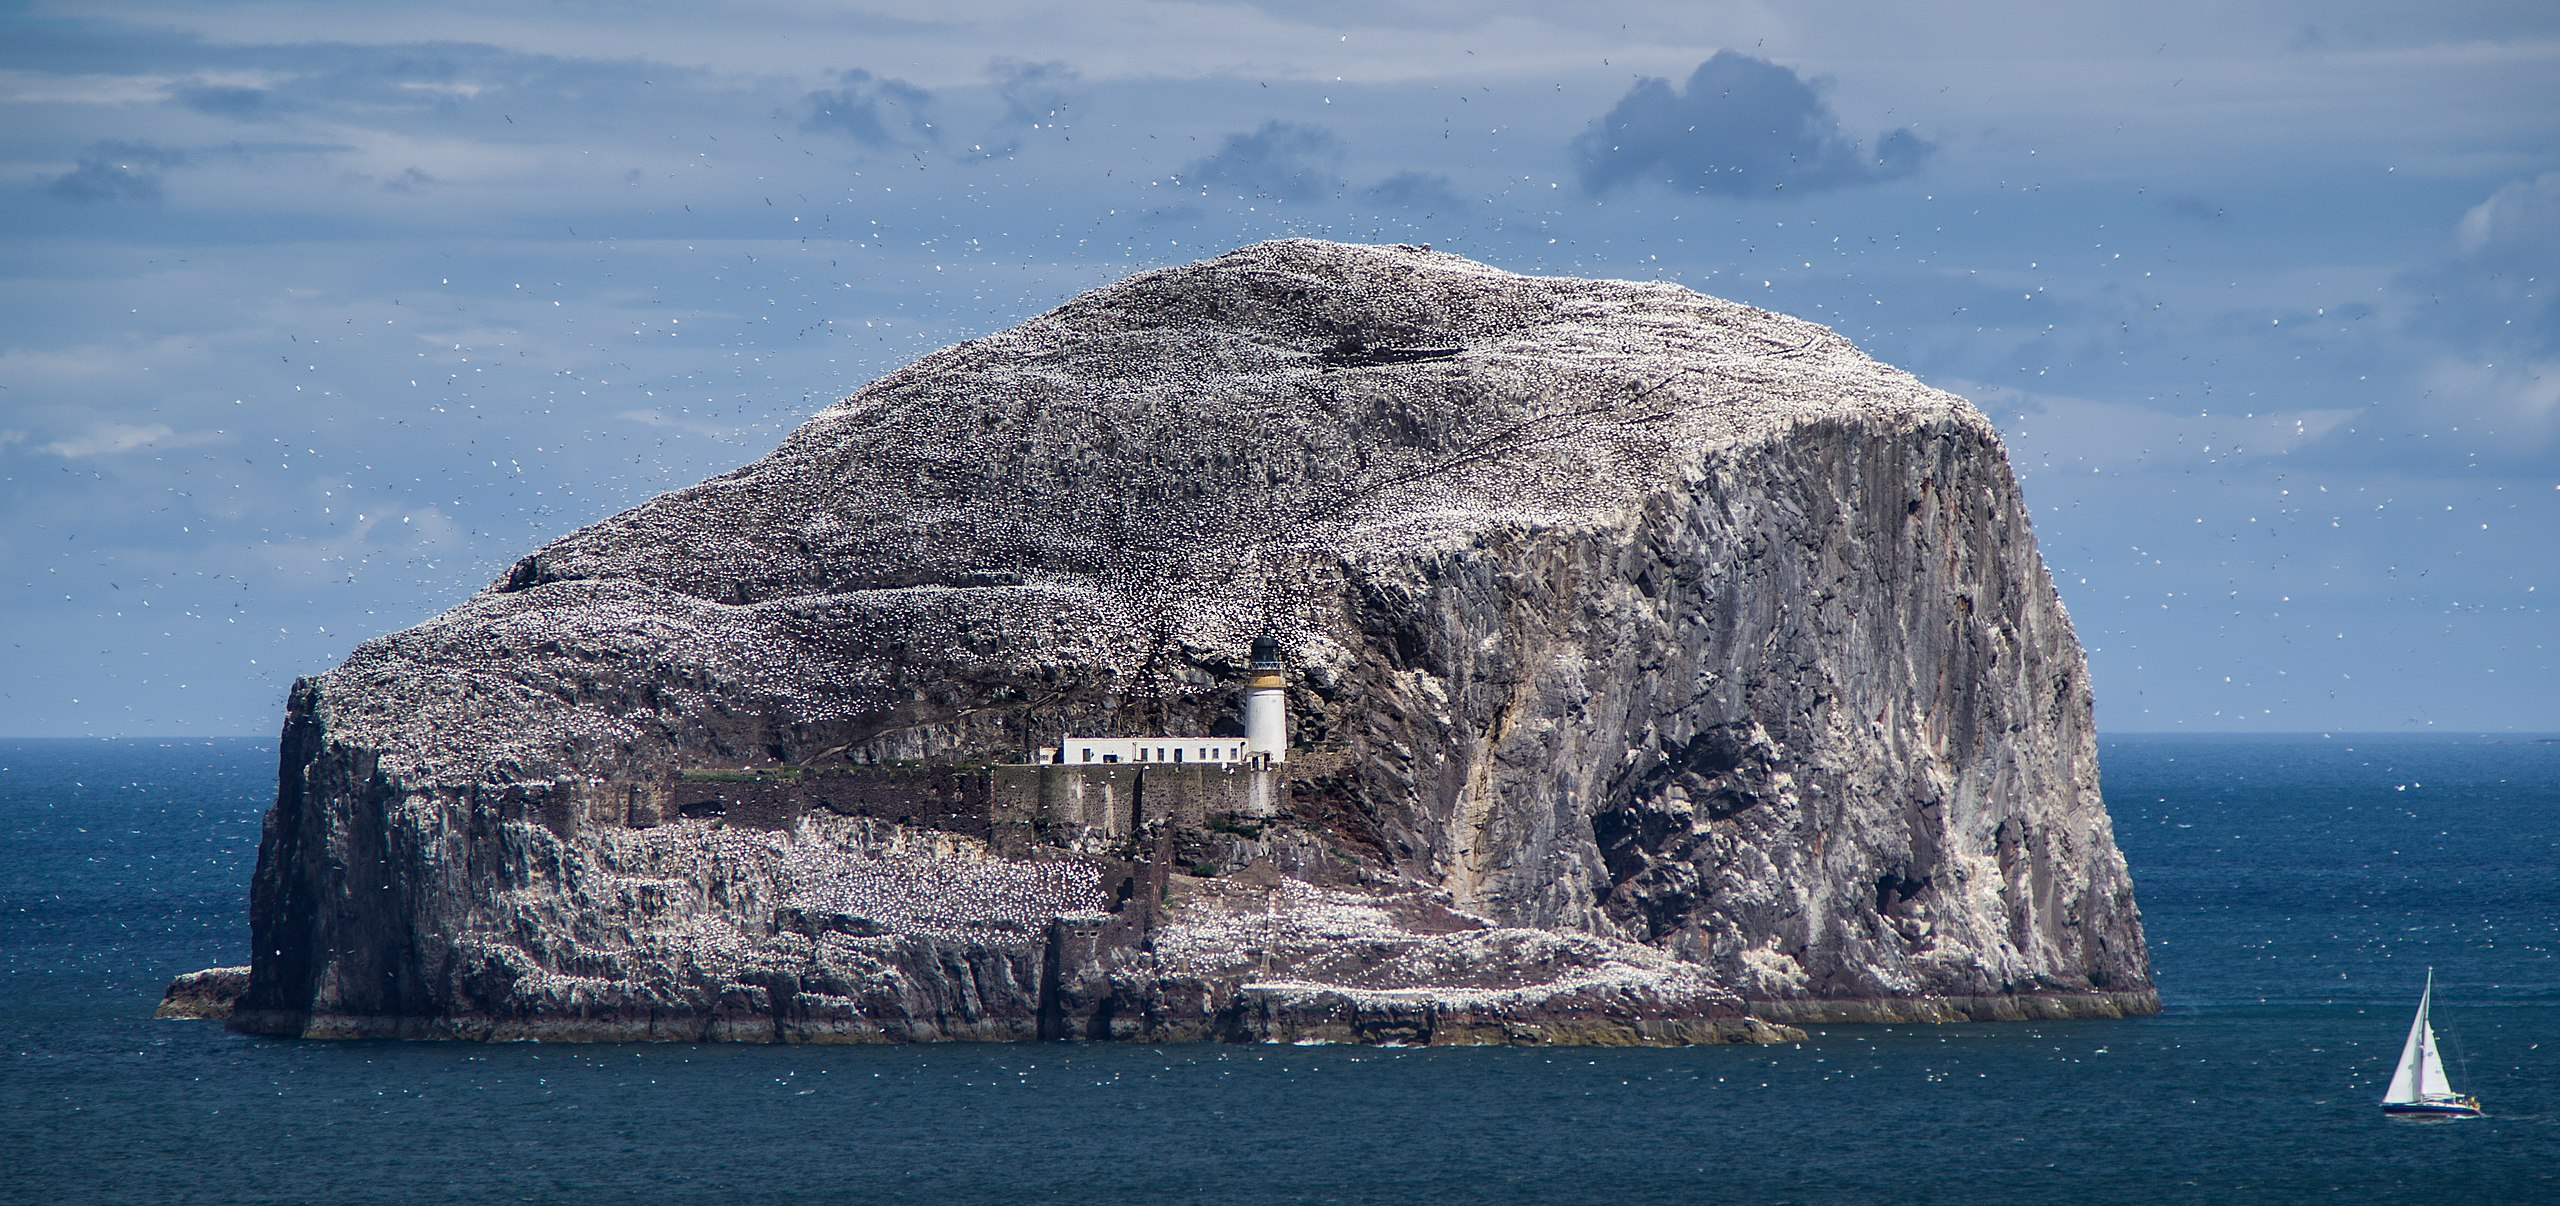
</div>

That is what we are really interested in, not our tiny sample of ten pairs.

# The correlation coefficient of the whole population is denoted $\rho$

<div>
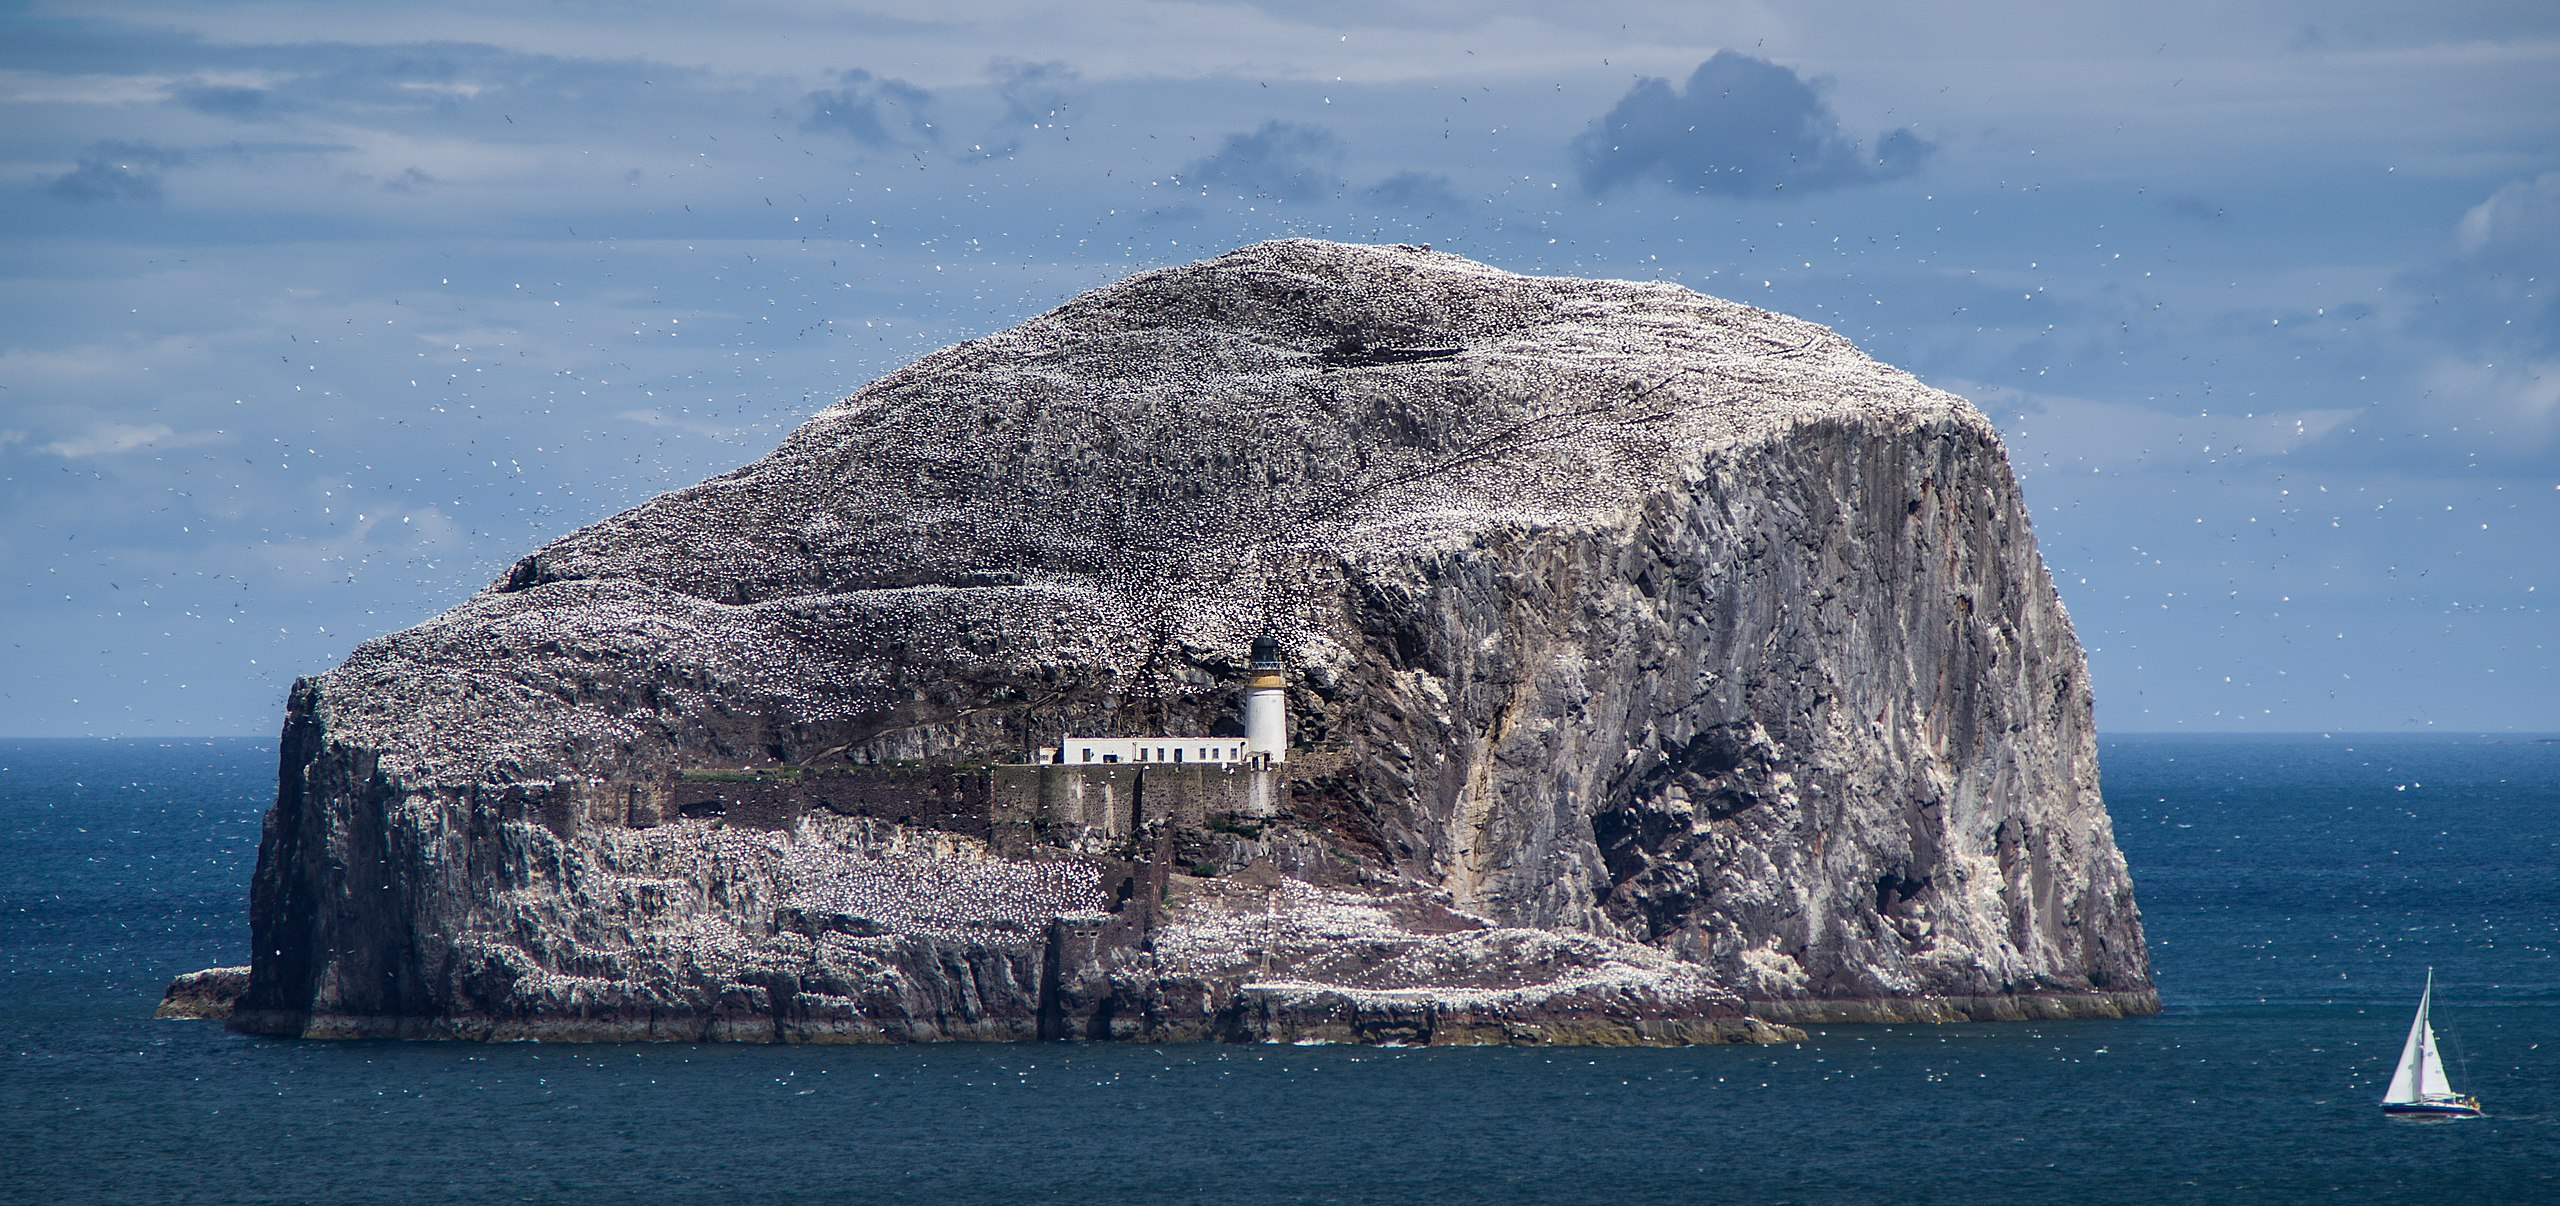
</div>

This is to distinguish it from the correlation coefficient of a small sample, denoted *r*.

Clearly, we cannot observe arrival days of all 104,000 gannets.

This means we can **never** know the actual value of ρ.

But we can estimate it to within some level of precision.

# The correlation coefficient of the whole population is denoted $\rho$

<div>
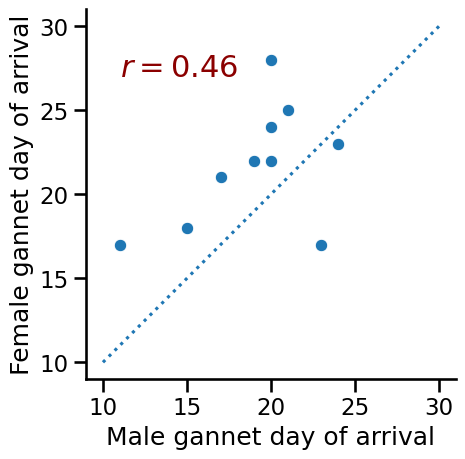
</div>

Our estimate of ρ (based on our sample of ten pairs) is 0.46.

# The correlation coefficient of the whole population is denoted $\rho$

<div>
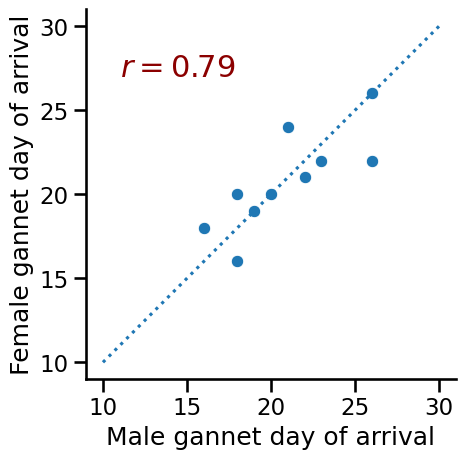
</div>

But if we took a different sample of ten pairs we would get a different estimate of ρ, 

e.g. *r* = 0.79.

Hypothetically, we could keep taking samples of ten pairs and estimate ρ for each.

This results in a range of estimates for ρ.

This range is called a 95% confidence interval (CI).

# Calculate the 95% CI of our sample

<div>
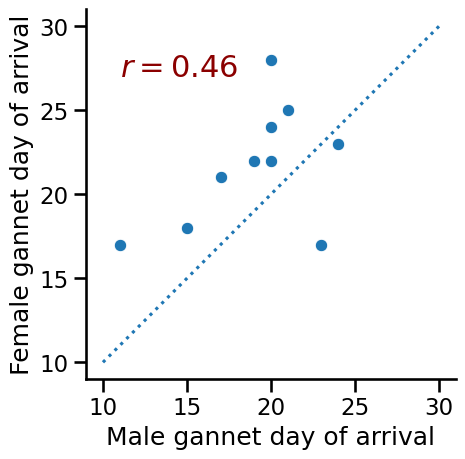
</div>

Fortunately we can calculate a 95% CI from our single sample.

This has already been done for us using some clever maths.

We just need to access it using python commands.

In [27]:
result = pearsonr( gannets['female'], gannets['male'] )

ci = result.confidence_interval()

print(f'lower bound of 95% CI = {ci.low:.2f}')
print(f'upper bound of 95% CI = {ci.high:.2f}')

lower bound of 95% CI = -0.24
upper bound of 95% CI = 0.85


<div>
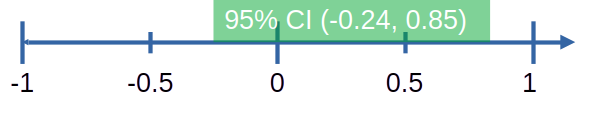
</div>


# An estimate of the correlation coefficient of arrival times of all breeding pairs of gannets on Bass Rock

<div>
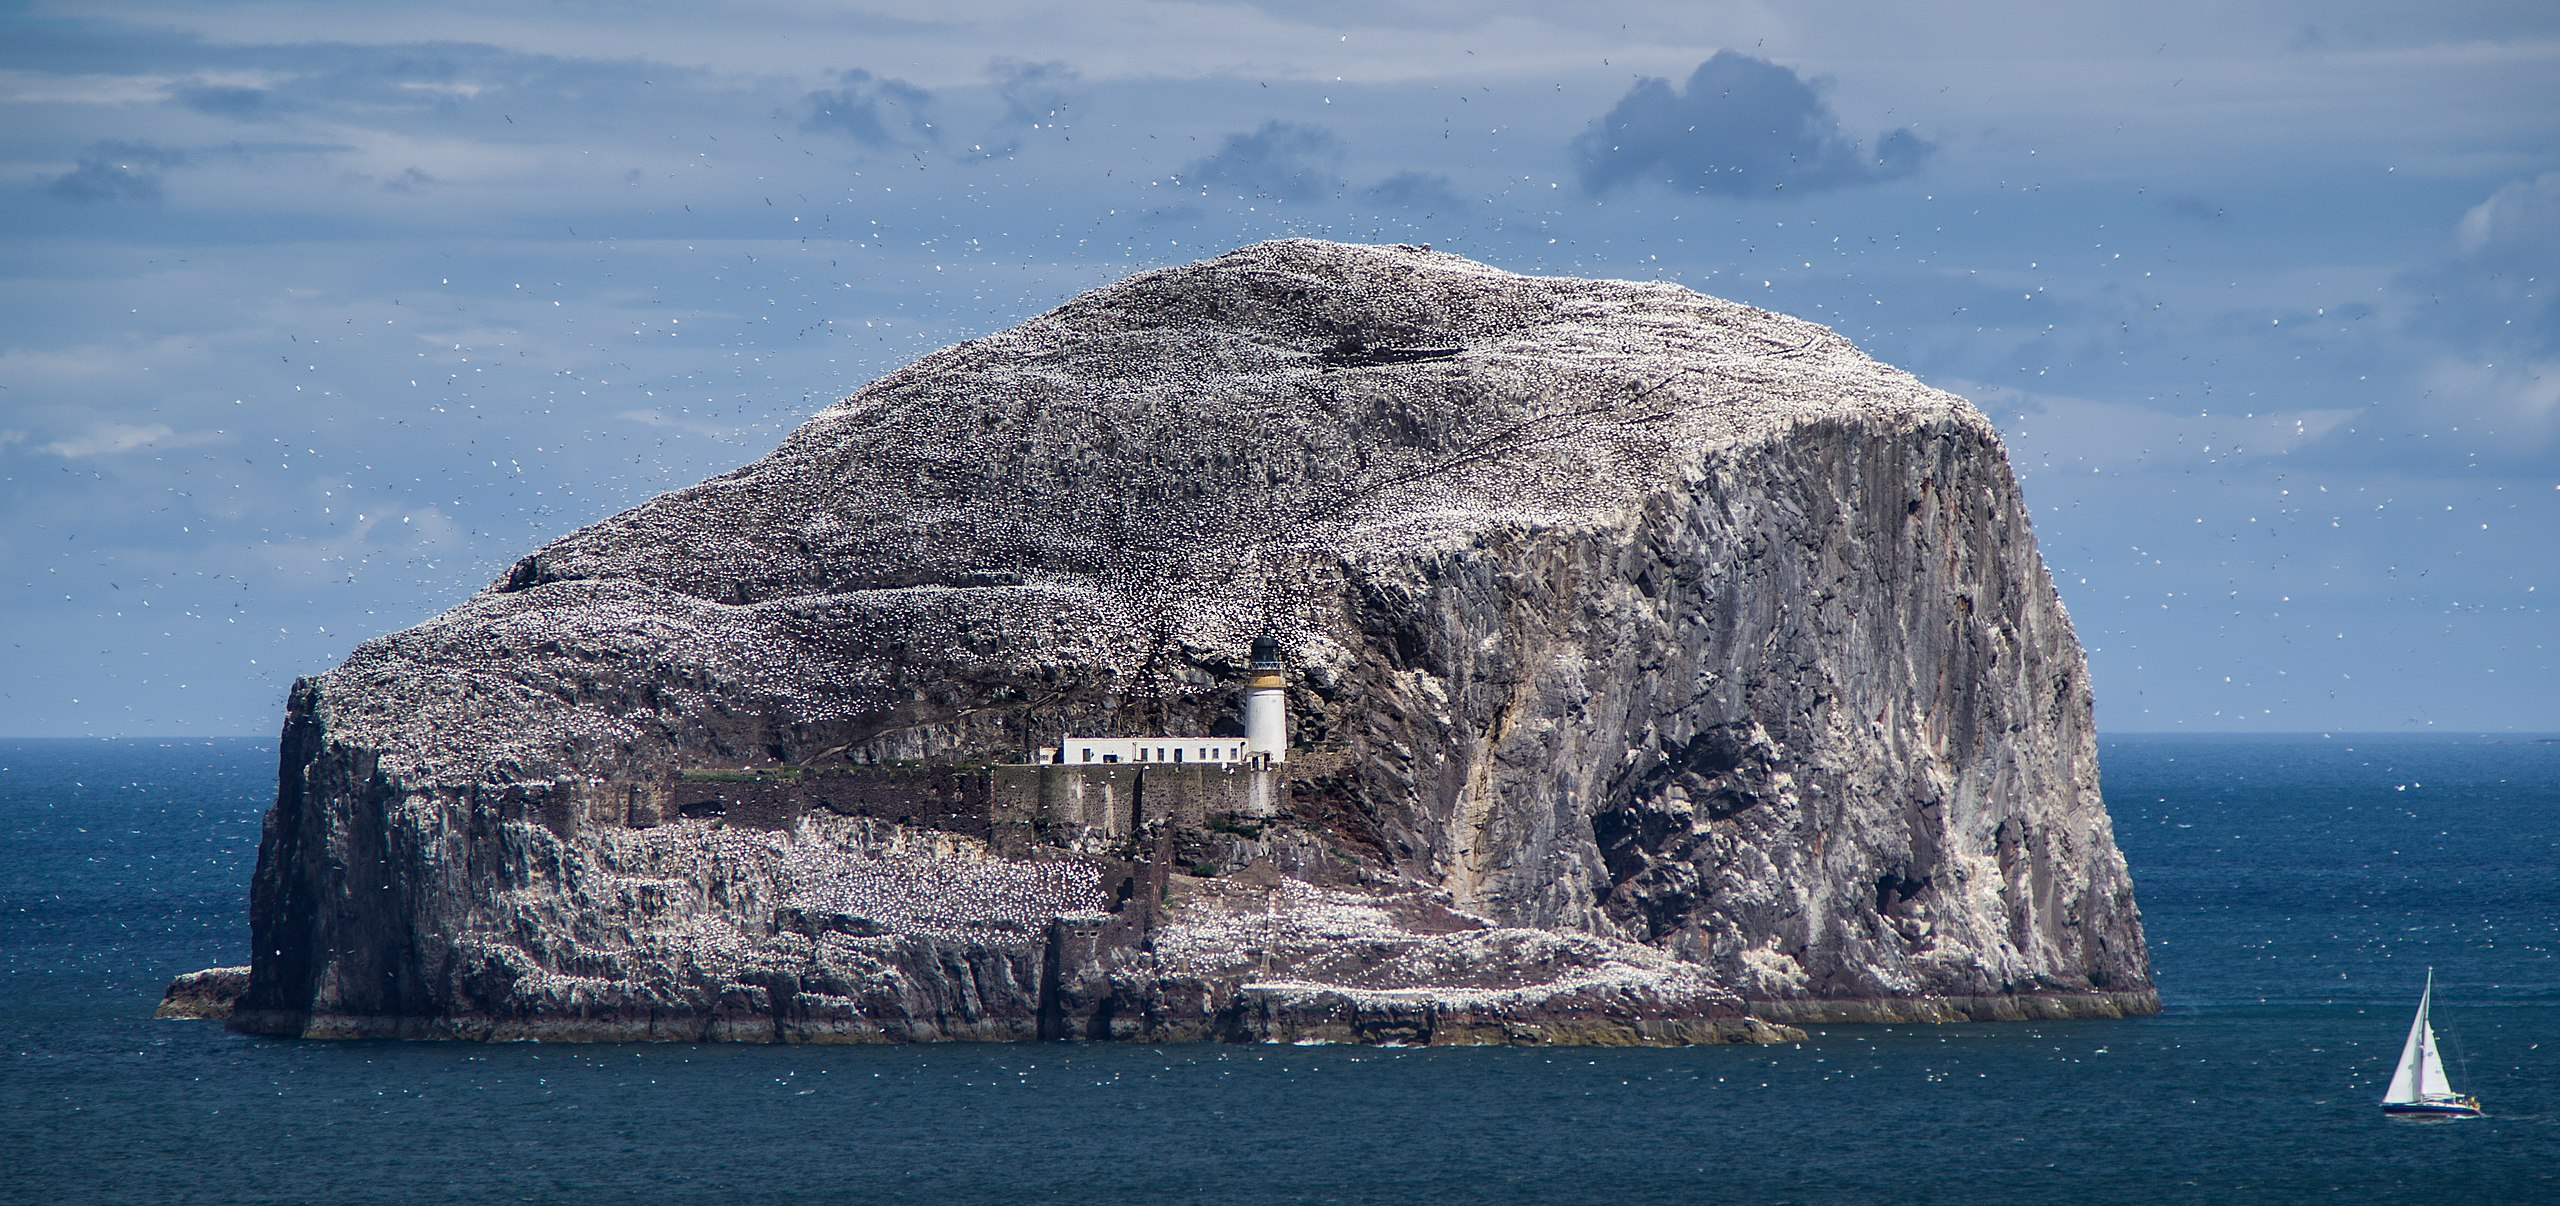
</div>

Point estimate is *r* = 0.46

Interval estimate is 95% CI = (-0.24, 0.85)


# How to interpret a 95% CI

The best interpretation of a 95%CI is as a measure of precision. 

What do we mean by precision? 

<div>
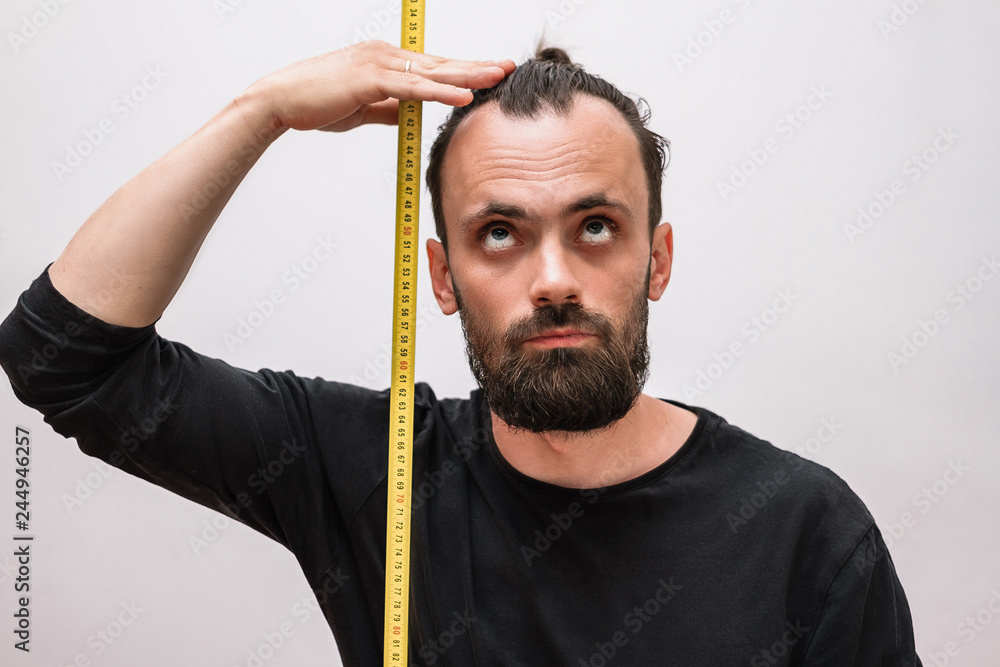
</div>

With a tape measure you could measure your height to the nearest cm (eg, height is 181 cm $\pm$ 1 cm)

<div>
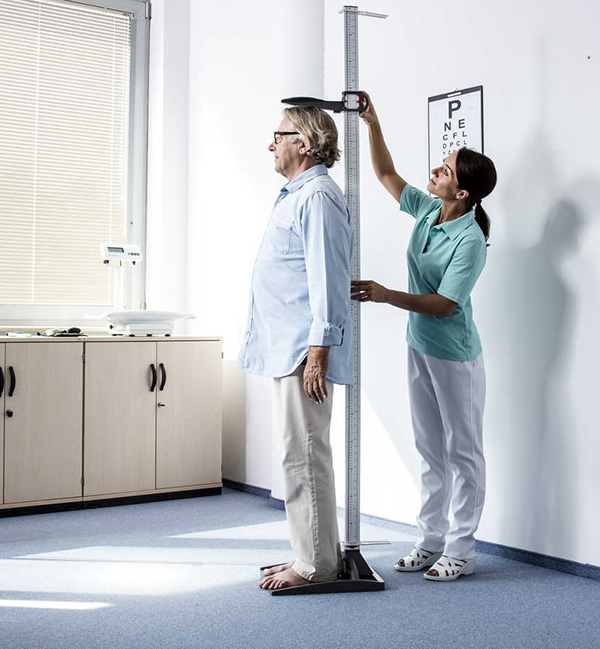
</div>

With a stadiometer you could measure your height to the nearest mm (eg, 181.3 mm $\pm$ 1 mm) - ten times more precise

In the scientific method we get more precision by careful measurement and **taking larger samples**.

# How sample size affects a 95% CI

In [ ]:
CI_demo();


# Are arrival times of a male and female breeding pair correlated?

We estimated the population correlation coefficient to be 0.46 with a 95% CI between -0.24 and 0.85.

But does this mean that arrival times of a male and female breeding pair actually correlated?

Let's examine the probability of observing a **sample** correlation coefficient of *r* = 0.46 for different values of the **population** correlation coefficient ρ.

# The probability our data gives *r* = 0.46 for different values of $\rho$

In [ ]:
cor_coef_prob_demo(n=10);

# Are arrival times of a male and female breeding pair correlated?

Let's assume for the moment that they are **not** correlated.

That means the correlation coefficient of arrival times of the whole population is zero. 

ρ = 0

# Are arrival times of a male and female breeding pair correlated?

<div>
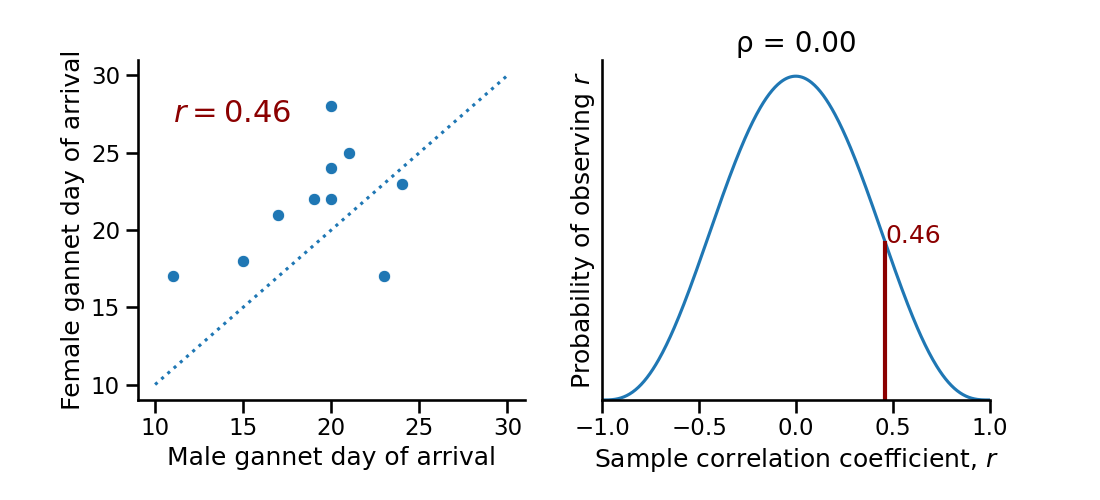
</div>

Assuming that ρ = 0, what is the probability of sampling ten breeding pairs with an *r* of at least 0.46?

It looks quite probable.

This probability is called a *p*-value.

# Are arrival times of a male and female breeding pair correlated?

<div>
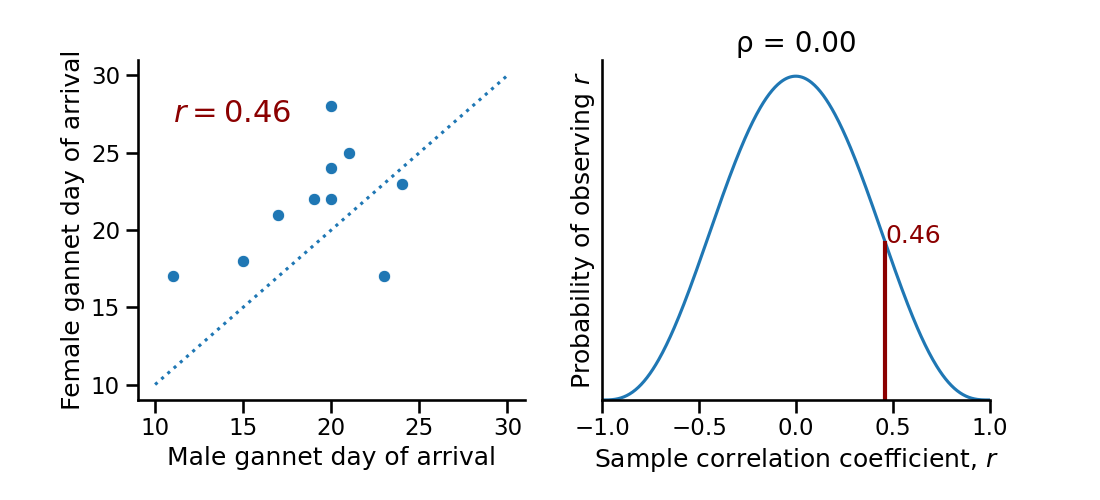
</div>

In [30]:
result = pearsonr( gannets['female'], gannets['male'] )

print( f'r = {result.statistic:.2f}' )
print( f'p = {result.pvalue:.2f} or {result.pvalue:.0%}' )

r = 0.46
p = 0.18 or 18%


# Are arrival times of male and female breeding pairs correlated?

<div>
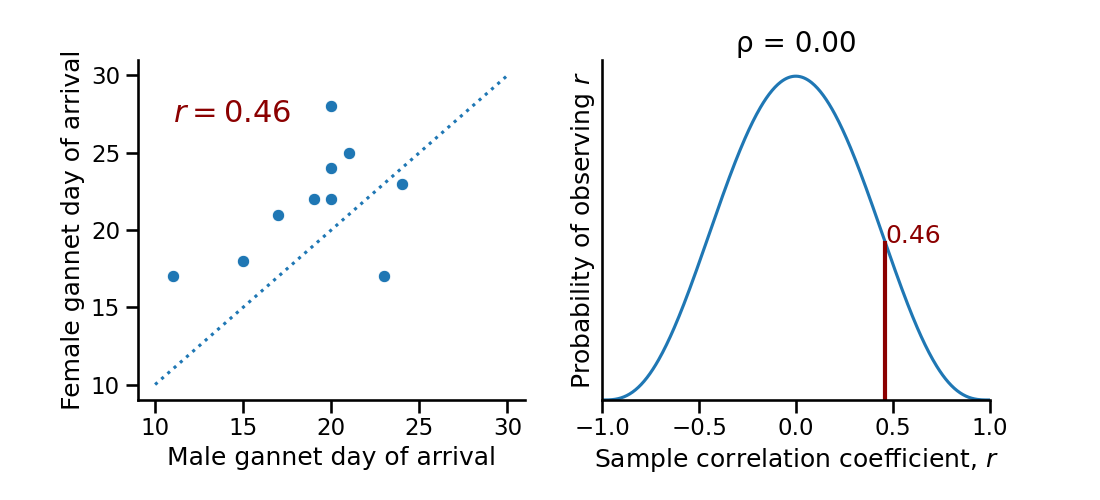
</div>

The probability of sampling ten breeding pairs with *r* at least 0.46, **assuming that ρ = 0**, is **18%**.

That's about a 1 in 5 chance. So actually quite likely.

*r* equal to 0.46 could have arisen by random chance alone even when the population correlation coefficient is zero. 

So there's a good chance that arrival times of breeding pairs are **not** correlated.

# Inferential statistics

Let's do all this more formally as you would in a scientific report, paper or poster.

First some definitions.

# Inferential statistics

## Definitions: Samples and Populations

A sample is usually a tiny subset of a much larger population of interest.

Ideally the sample is made up of individuals taken randomly from the population.

### For example

A **sample** of ten male and female breeding pairs of gannets randomly sampled from the **population** of 52,000 breeding pairs on Bass Rock.

# Inferential statistics

## Definitions: Statistics and Parameters

A statistic is a numerical property of a sample.

A parameter is the same property but of the population.

property | sample statistic | population parameter
:--- | :---: | :---:
correlation coefficient | *r* | ρ 
mean | $\bar{x}$ | μ
standard deviation | *s* | σ 

### For example

The correlation coefficient of our **sample** of arrival times of ten breeding pairs is a **statistic** denoted by *r*.

The correlation coefficient of the **population** of arrival times of breeding pairs is a **parameter** denoted by ρ.

## Defintion: Inferential statistics

The drawing of conclusions (inferences) about a population using a random sample taken from that population.

### For example

Based on our sample of 10 pairs we can make following inferences about the population of 52,000 pairs:
1. estimate ρ 
    - point and 95% confidence interval estimates
2. ask whether ρ is equal to zero (there is no correlation) or not equal to zero (there is a correlation).
    - Null hypothesis significance testing

# Null hypothesis significance testing

1. Select a test statistic that measures an effect or a difference or a change in one or more samples.

# Null hypothesis significance testing

2. Set up two statistical hypotheses

- the null hypothesis H<sub>0</sub> 
    - the hypothesis of no effect or no difference or no change (population parameter equals zero) 

- the alternative hypothesis H<sub>A</sub> or H<sub>1</sub> 
    - the hypothesis of an effect or difference or change (population parameter does not equal zero)

# Null hypothesis significance testing

3. Test the null by asking the question:

    "What is the probability of observing a test statistic as extreme as we did **assuming the null hypothesis is true?**"

    This probability is called a *p*-value.

# Null hypothesis significance testing

4. Make a decision to reject or not reject the null hypothesis

- If *p* is high, our data and the test statistic is **consistent** with the null hypothesis.
    - We fail to reject the null hypothesis. We have what's called a **non-significant** result.
- If *p* is low, our data and the test statistic is **inconsistent** with the null hypothesis.
    - We reject the null hypothesis. We have what's called a **significant** result.

What is considered low for *p*? 

The usual value in the Biological and Medical Sciences is *p* less than 5% or 0.05. 

This value is completely arbitrary and has no scientific justification. It is a convention.

# Null hypothesis significance testing

5. Report the outcome of the test.

# Are arrival times of a male and female breeding pair correlated?

1. Select a test statistic.

    - *r*, the correlation coefficient of male and female breeding pair arrival times. 

# Are arrival times of a male and female breeding pair correlated?

2. Set up two hypotheses

    - Null hypothesis: ρ = 0
    - Alternative hypothesis: ρ $\ne$ 0

# Are arrival times of a male and female breeding pair correlated?

3. Test the null hypothesis:

    ```python
    result = pearsonr( gannets['female'], gannets['male'] )
    print( f'p = {result.pvalue:.2f}' )
    ```

    - *p* = 0.18

# Are arrival times of male and female breeding pairs correlated?

4. Make a decision:

    - *p* > 0.05, therefore I fail to reject the null hypothesis

# Are arrival times of a male and female breeding pair correlated?

5. Report the outcome:

    - "There was no evidence of a correlation between male and female breeding pair arrival times on Bass Rock (*n* = 10, *r* = 0.46, 95% CI = (－0.24, 0.85), *p* = 0.18)."

# Inferential statistics workflow in python

# Inferential statistics workflow in python

1. Read in the data and look at it (clean if necessary)

In [31]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

gannets = pd.read_csv('../Datasets/gannets.csv')
gannets

,pair,male,female
0,1,19,22
1,2,20,28
2,3,23,17
3,4,17,21
4,5,15,18
5,6,24,23
6,7,11,17
7,8,21,25
8,9,20,24
9,10,20,22


# Inferential statistics workflow in python
2. Calculate the sample's correlation coefficient

In [32]:
result = pearsonr( gannets['male'], gannets['female'] )
result.statistic

0.4604386587976584

# Inferential statistics workflow in python
3. Calculate the sample's 95% CI

In [33]:
ci = result.confidence_interval()
ci.low, ci.high

(-0.2382603345436158, 0.8450742960023483)

# Inferential statistics workflow in python

4. Test the null hypothesis by calculating a *p*-value

In [34]:
result.pvalue

0.18053191584077594

# Inferential statistics workflow in python

5. Report the result

    "There was no evidence of a correlation between male and female breeding pair arrival times on Bass Rock (*n* = 10, *r* = 0.46, 95% CI = (－0.24, 0.85), *p* = 0.18)."


# Class 9: Inferential statistics

## Noteable

### Folder: 2025-DExB2/Week_05


- lecture_9.ipynb (this lecture)

- gannet_arrivals_workflow.ipynb (NHST of the correlation coefficient of gannet arrival times)

- Class_9.ipynb (today's notebook for you to practice inferential stats)

Ignore the other files, they are for Friday.